In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

from pathlib import Path

carpeta = Path("../images")
carpeta.mkdir(parents=True, exist_ok=True)


Generando Gráfico 1: Zona Segura...


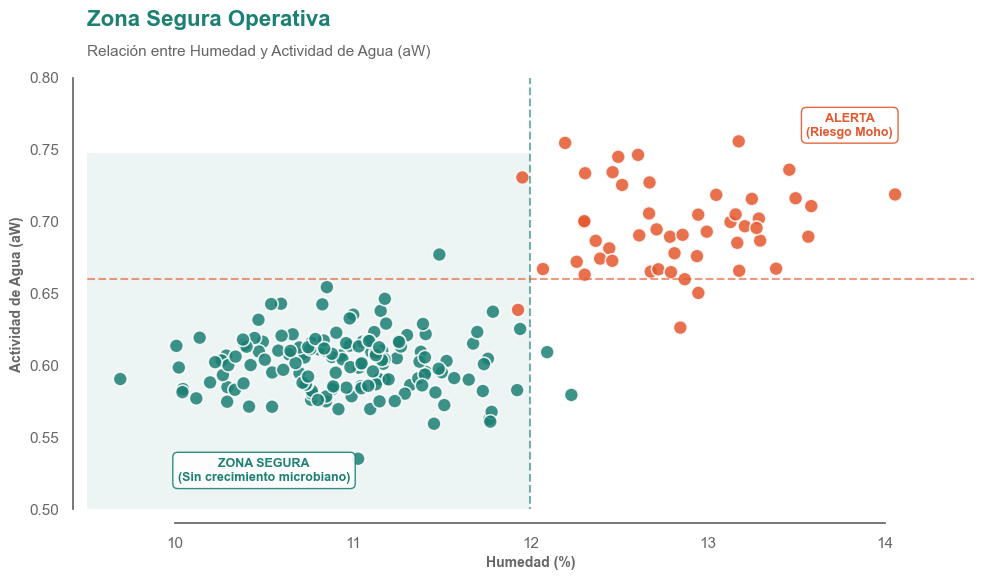

Generando Gráfico 2: Estabilidad vs Prevalencia...


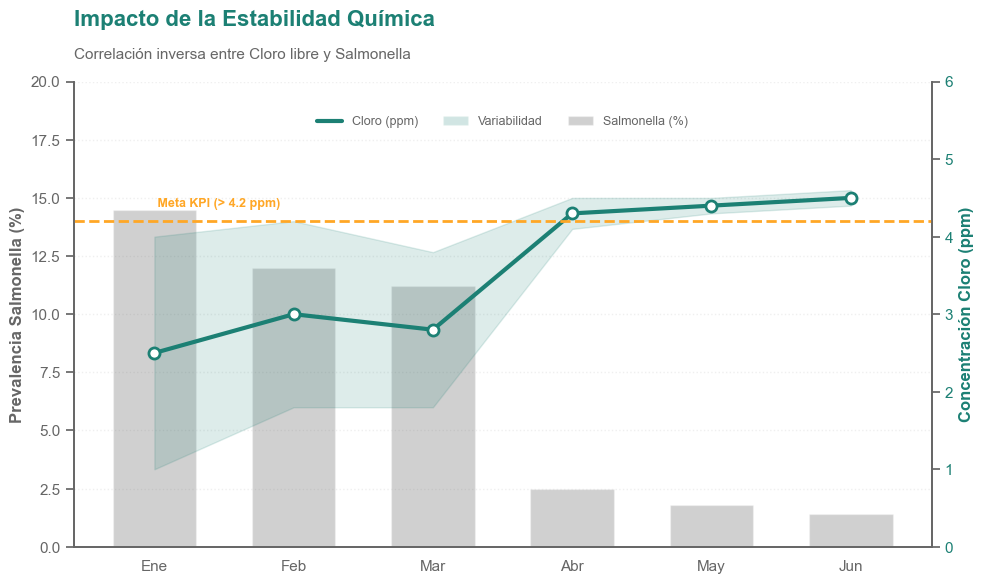

Generando Gráfico 3: Matriz de Riesgo...


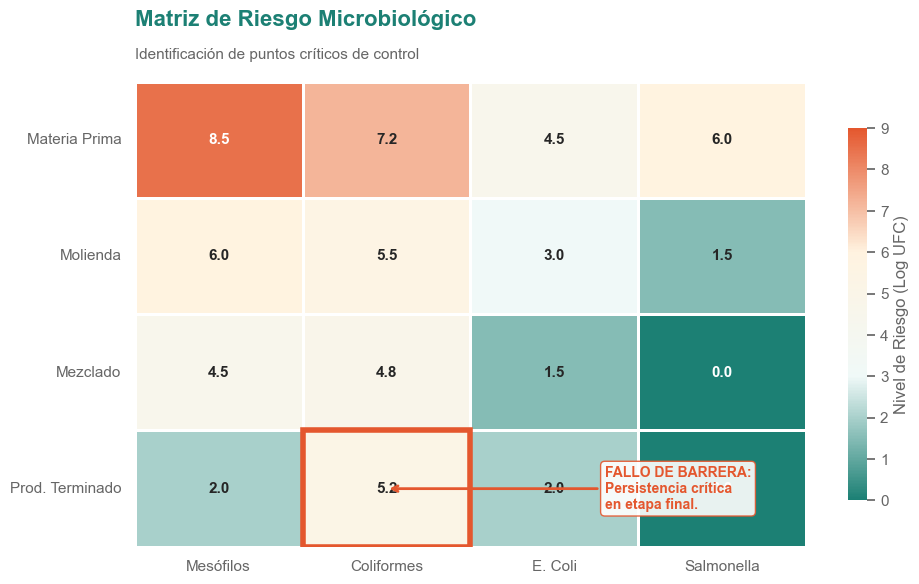


¡Proceso completado! Se han guardado 3 imágenes HQ en tu carpeta.


In [16]:


# --- 1. CONFIGURACIÓN DE IDENTIDAD VISUAL ---
# Paleta exacta proporcionada
PALETTE = {
    'Teal': '#1C8074',   # Principal / Seguro / Positivo
    'Grey': '#666666',   # Texto / Neutro / Secundario
    'Red': '#E4572E',    # Riesgo / Alerta / Acento
    'Blue': '#29B6F6',   # Informativo / Datos de soporte
    'Yellow': '#FFA726'  # Advertencia / Transición
}

# Configuración global de estilo para Alta Calidad
sns.set_theme(style="white", rc={
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "grid.color": "#E0E0E0",
    "grid.linestyle": ":",
    "axes.edgecolor": PALETTE['Grey'],
    "axes.labelcolor": PALETTE['Grey'],
    "xtick.color": PALETTE['Grey'],
    "ytick.color": PALETTE['Grey'],
    "text.color": PALETTE['Grey'],
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"]
})

# Función auxiliar para títulos estilo "Dashboard"
def set_dashboard_title(ax, title, subtitle):
    ax.text(x=0, y=1.12, s=title, transform=ax.transAxes, 
            fontsize=16, weight='bold', color=PALETTE['Teal'], ha='left')
    ax.text(x=0, y=1.05, s=subtitle, transform=ax.transAxes, 
            fontsize=11, weight='normal', color=PALETTE['Grey'], ha='left')

# --- GRÁFICA 1: LA ZONA SEGURA (SCATTER PLOT) ---
def plot_safe_zone():
    print("Generando Gráfico 1: Zona Segura...")
    np.random.seed(42)
    # Datos simulados
    n_safe = 150
    hum_safe = np.random.normal(11.0, 0.5, n_safe)
    aw_safe = np.random.normal(0.60, 0.02, n_safe)
    
    n_risk = 50
    hum_risk = np.random.normal(12.8, 0.6, n_risk)
    aw_risk = np.random.normal(0.69, 0.03, n_risk)
    
    hum = np.concatenate([hum_safe, hum_risk])
    aw = np.concatenate([aw_safe, aw_risk])
    status = ['Controlado'] * n_safe + ['Riesgo'] * n_risk
    df = pd.DataFrame({'Humedad': hum, 'aW': aw, 'Estado': status})
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. Zona Segura (Área sombreada)
    ax.axvspan(0, 12.0, ymin=0, ymax=(0.66/0.8), color=PALETTE['Teal'], alpha=0.08, lw=0)
    
    # Líneas de límite
    ax.vlines(x=12.0, ymin=0, ymax=0.8, color=PALETTE['Teal'], linestyle='--', alpha=0.6)
    ax.hlines(y=0.66, xmin=0, xmax=16, color=PALETTE['Red'], linestyle='--', alpha=0.6)

    # 2. Scatter Plot
    colors = {'Controlado': PALETTE['Teal'], 'Riesgo': PALETTE['Red']}
    sns.scatterplot(data=df, x='Humedad', y='aW', hue='Estado', palette=colors, 
                    s=100, alpha=0.85, edgecolor='white', linewidth=1.2, ax=ax)
    
    # 3. Textos y Anotaciones
    set_dashboard_title(ax, 'Zona Segura Operativa', 'Relación entre Humedad y Actividad de Agua (aW)')
    
    ax.set_xlabel('Humedad (%)', fontweight='bold', fontsize=10)
    ax.set_ylabel('Actividad de Agua (aW)', fontweight='bold', fontsize=10)
    ax.set_xlim(9.5, 14.5)
    ax.set_ylim(0.50, 0.80)
    
    # Etiquetas directas
    ax.text(10.5, 0.52, 'ZONA SEGURA\n(Sin crecimiento microbiano)', 
            color=PALETTE['Teal'], fontsize=9, ha='center', fontweight='bold',
            bbox=dict(facecolor='white', edgecolor=PALETTE['Teal'], boxstyle='round,pad=0.4', alpha=0.9))
            
    ax.text(13.8, 0.76, 'ALERTA\n(Riesgo Moho)', 
            color=PALETTE['Red'], fontsize=9, ha='center', fontweight='bold',
            bbox=dict(facecolor='white', edgecolor=PALETTE['Red'], boxstyle='round,pad=0.4', alpha=0.9))

    ax.legend().remove()
    sns.despine(offset=10, trim=True)
    plt.tight_layout()
    
    # GUARDAR EN ALTA RESOLUCIÓN
    plt.savefig('../images/1_zona_segura_HQ.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# --- GRÁFICA 2: ESTABILIDAD VS PREVALENCIA (DUAL AXIS MEJORADO) ---
def plot_stability_vs_prevalence():
    print("Generando Gráfico 2: Estabilidad vs Prevalencia...")
    months = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
    cloro_mean = [2.5, 3.0, 2.8, 4.3, 4.4, 4.5]
    cloro_std = [1.5, 1.2, 1.0, 0.2, 0.1, 0.1]
    salmonella_prev = [14.5, 12.0, 11.2, 2.5, 1.8, 1.4]
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    set_dashboard_title(ax1, 'Impacto de la Estabilidad Química', 
                        'Correlación inversa entre Cloro libre y Salmonella')

    # Eje 1: Barras (Prevalencia)
    ax1.bar(months, salmonella_prev, color=PALETTE['Grey'], alpha=0.3, width=0.6, label='Prevalencia Salmonella')
    ax1.set_ylabel('Prevalencia Salmonella (%)', color=PALETTE['Grey'], fontweight='bold')
    ax1.set_ylim(0, 20)
    
    # Eje 2: Línea (Cloro)
    ax2 = ax1.twinx()
    
    # Banda de confianza
    upper = [m + s for m, s in zip(cloro_mean, cloro_std)]
    lower = [m - s for m, s in zip(cloro_mean, cloro_std)]
    ax2.fill_between(months, lower, upper, color=PALETTE['Teal'], alpha=0.15, label='Variabilidad Proceso')
    
    # Línea principal
    ax2.plot(months, cloro_mean, color=PALETTE['Teal'], marker='o', linewidth=3, 
             markersize=8, markerfacecolor='white', markeredgewidth=2, label='Conc. Cloro (ppm)')
    
    ax2.set_ylabel('Concentración Cloro (ppm)', color=PALETTE['Teal'], fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=PALETTE['Teal'])
    ax2.set_ylim(0, 6)
    
    # Línea de Meta (KPI)
    ax2.axhline(y=4.2, color=PALETTE['Yellow'], linestyle='--', linewidth=2)
    ax2.text(0, 4.35, ' Meta KPI (> 4.2 ppm)', color=PALETTE['Yellow'], fontsize=9, fontweight='bold', va='bottom')

    # Leyenda unificada
    legend_elements = [
        Line2D([0], [0], color=PALETTE['Teal'], lw=3, label='Cloro (ppm)'),
        Patch(facecolor=PALETTE['Teal'], alpha=0.2, label='Variabilidad'),
        Patch(facecolor=PALETTE['Grey'], alpha=0.3, label='Salmonella (%)')
    ]
    
    ax1.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95), 
               ncol=3, frameon=False, fontsize=9)
    
    ax2.grid(False)
    ax1.grid(axis='y', linestyle=':', alpha=0.5)
    sns.despine(right=False, top=True)
    plt.tight_layout()
    
    # GUARDAR EN ALTA RESOLUCIÓN
    plt.savefig('../images/2_estabilidad_prevalencia_HQ.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# --- GRÁFICA 3: MAPA DE CALOR (RISK MATRIX) ---
def plot_heatmap_risk():
    print("Generando Gráfico 3: Matriz de Riesgo...")
    stages = ['Materia Prima', 'Molienda', 'Mezclado', 'Prod. Terminado']
    microorgs = ['Mesófilos', 'Coliformes', 'E. Coli', 'Salmonella']
    
    data = np.array([
        [8.5, 7.2, 4.5, 6.0],
        [6.0, 5.5, 3.0, 1.5],
        [4.5, 4.8, 1.5, 0.0],
        [2.0, 5.2, 2.0, 0.0]
    ])
    
    # Colormap: Teal (Seguro) -> Blanco (Medio) -> Rojo (Riesgo)
    # Usamos colores intermedios suaves para que la transición sea elegante
    cmap = LinearSegmentedColormap.from_list('CorpRisk', [PALETTE['Teal'], '#F0F9F8', '#FFF3E0', PALETTE['Red']])

    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.heatmap(data, annot=True, cmap=cmap, xticklabels=microorgs, yticklabels=stages, 
                linewidths=2, linecolor='white', fmt='.1f', vmin=0, vmax=9,
                cbar_kws={'label': 'Nivel de Riesgo (Log UFC)', 'shrink': 0.8},
                annot_kws={'size': 11, 'weight': 'bold'})
    
    set_dashboard_title(ax, 'Matriz de Riesgo Microbiológico', 'Identificación de puntos críticos de control')

    # Resaltar Hallazgo
    rect = Rectangle((1, 3), 1, 1, fill=False, edgecolor=PALETTE['Red'], lw=4, zorder=5)
    ax.add_patch(rect)
    
    # Anotación
    ax.annotate('FALLO DE BARRERA:\nPersistencia crítica\nen etapa final.',
                xy=(1.5, 3.5), xycoords='data',
                xytext=(2.8, 3.5), textcoords='data',
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color=PALETTE['Red'], lw=2),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PALETTE['Red'], alpha=0.9),
                fontsize=10, color=PALETTE['Red'], fontweight='bold', ha='left', va='center')

    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # GUARDAR EN ALTA RESOLUCIÓN
    plt.savefig('../images/3_matriz_riesgo_HQ.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# --- EJECUCIÓN ---
if __name__ == "__main__":
    plot_safe_zone()
    plot_stability_vs_prevalence()
    plot_heatmap_risk()
    print("\n¡Proceso completado! Se han guardado 3 imágenes HQ en tu carpeta.")